# Evaluacion de Modelos LSM (ONNX) — genero, numeros, dias, meses, huespedes

Notebook de evaluacion para la defensa. **No re-entrena los modelos entregados**: los carga
desde sus `.onnx` y mide su desempeno. Los *mini-benchmarks* (ADR-08 / ADR-09) si entrenan
modelos alternativos para justificar la eleccion de arquitectura.

Los datos `.npy` viven en distintas **ramas de git**; este notebook los extrae automaticamente
con `git archive` (sin cambiar de rama ni tocar tu working tree):

| Modelo | Datos (rama) | Clases |
|---|---|---|
| genero    | working tree (`model/data`) | femenino, masculino |
| numeros   | `feature/numeros` | 0–9 |
| dias      | `feature/dias`    | 7 dias |
| meses     | `feature/meses`   | 12 meses |
| huespedes | `ttfinal`         | 1, 2, 3, adulto, nino |

> **Nota metodologica.** Cada modelo se evalua sobre un split estratificado reproducible
> (`random_state=42`, `test_size=0.2`), el mismo que produce `train_model.py`. Si el modelo
> se entreno con ese pipeline, este split reproduce su conjunto de validacion (sin fuga de datos).

## 0. Instalacion de dependencias
Ejecuta esta celda una sola vez.

In [1]:
%pip install numpy pandas scikit-learn matplotlib seaborn onnx onnxruntime xgboost tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports y configuracion

In [2]:
import os, io, json, glob, subprocess, tarfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import onnx, onnxruntime as ort
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
TEST_SIZE = 0.2
np.random.seed(RANDOM_STATE)

# Raiz del repo (para git archive y rutas a los .onnx)
REPO_ROOT = subprocess.run(['git', 'rev-parse', '--show-toplevel'],
                           capture_output=True, text=True).stdout.strip()
if not REPO_ROOT:
    REPO_ROOT = os.path.abspath('..')
CACHE_DIR = os.path.join(REPO_ROOT, 'model', 'eval_datasets')
print('REPO_ROOT :', REPO_ROOT)
print('CACHE_DIR :', CACHE_DIR)

REPO_ROOT : C:/Users/leona/OneDrive/Desktop/repo/LSM/2
CACHE_DIR : C:/Users/leona/OneDrive/Desktop/repo/LSM/2\model\eval_datasets


## 2. Configuracion de los modelos
Cada entrada apunta a su `.onnx`, su `label_map.json` y la fuente de datos.
`data_branch = None` significa "leer del working tree actual" (caso de genero).

In [3]:
MODELS = [
    {'name': 'genero',    'onnx': 'modelosLSMTT4/models/genero.onnx',
     'labels': 'modelosLSMTT4/models/genero_label_map.json',  'data_branch': None},
    {'name': 'numeros',   'onnx': 'modelosLSMTT4/models/numeros.onnx',
     'labels': 'modelosLSMTT4/models/numeros_label_map.json', 'data_branch': 'feature/numeros'},
    {'name': 'dias',      'onnx': 'modelosLSMTT4/models/dias.onnx',
     'labels': 'modelosLSMTT4/models/dias_label_map.json',    'data_branch': 'feature/dias'},
    {'name': 'meses',     'onnx': 'modelosLSMTT4/models/meses.onnx',
     'labels': 'modelosLSMTT4/models/meses_label_map.json',   'data_branch': 'feature/meses'},
    {'name': 'huespedes', 'onnx': 'modelosLSMTT4/models/huespedes.onnx',
     'labels': 'modelosLSMTT4/models/label_map.json',         'data_branch': 'ttfinal'},
]
for m in MODELS:
    m['onnx'] = os.path.join(REPO_ROOT, m['onnx'])
    m['labels'] = os.path.join(REPO_ROOT, m['labels'])
print('Modelos configurados:', [m['name'] for m in MODELS])

Modelos configurados: ['genero', 'numeros', 'dias', 'meses', 'huespedes']


## 3. Funciones reutilizables (datos, ONNX, metricas)

In [4]:
def load_label_names(path):
    """Lista ordenada por indice. Acepta {"0":"femenino"} o {"femenino":0}."""
    with open(path, 'r', encoding='utf-8') as fh:
        raw = json.load(fh)
    def is_int(s):
        try:    int(s); return True
        except (ValueError, TypeError): return False
    pairs = ({int(k): v for k, v in raw.items()} if all(is_int(k) for k in raw)
             else {int(v): k for k, v in raw.items()})
    return [pairs[i] for i in sorted(pairs)]


def extract_branch_data(branch, dest_dir):
    """Extrae <branch>:model/data/* a dest_dir/<clase>/*.npy via git archive (cachea)."""
    if os.path.isdir(dest_dir) and glob.glob(os.path.join(dest_dir, '*', '*.npy')):
        return dest_dir  # ya cacheado
    out = subprocess.run(['git', 'archive', branch, 'model/data'],
                         cwd=REPO_ROOT, capture_output=True)
    if out.returncode != 0:
        raise RuntimeError('git archive fallo en %s: %s'
                           % (branch, out.stderr.decode('utf-8', 'ignore')[:200]))
    prefix = 'model/data/'
    with tarfile.open(fileobj=io.BytesIO(out.stdout)) as tf:
        for mem in tf.getmembers():
            if mem.isfile() and mem.name.startswith(prefix) and mem.name.endswith('.npy'):
                target = os.path.join(dest_dir, mem.name[len(prefix):])
                os.makedirs(os.path.dirname(target), exist_ok=True)
                with open(target, 'wb') as fh:
                    fh.write(tf.extractfile(mem).read())
    return dest_dir


def data_dir_for(cfg):
    """Devuelve la carpeta con subcarpetas de clases para este modelo."""
    if cfg['data_branch'] is None:
        return os.path.join(REPO_ROOT, 'model', 'data')   # working tree (genero)
    return extract_branch_data(cfg['data_branch'], os.path.join(CACHE_DIR, cfg['name']))


def load_dataset(data_dir, class_names):
    """Carga SOLO las clases de class_names, en ese orden -> indices alineados al ONNX."""
    X, y, counts = [], [], {}
    for idx, c in enumerate(class_names):
        files = sorted(glob.glob(os.path.join(data_dir, c, '*.npy')))
        counts[c] = len(files)
        for f in files:
            X.append(np.load(f)); y.append(idx)
    if not X:
        raise FileNotFoundError('Sin .npy en %s para clases %s' % (data_dir, class_names))
    return np.array(X, np.float32), np.array(y, np.int64), counts


def onnx_predict(onnx_path, X):
    sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    name = sess.get_inputs()[0].name
    proba = sess.run(None, {name: X.astype(np.float32)})[0]
    return np.asarray(proba)


def plot_confusion(cm, class_names, title):
    plt.figure(figsize=(1.2 * len(class_names) + 2, len(class_names) + 1.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title); plt.xlabel('Prediccion'); plt.ylabel('Real')
    plt.tight_layout(); plt.show()


def most_confused(cm, class_names, top=10):
    pairs = [(class_names[i], class_names[j], int(cm[i, j]))
             for i in range(cm.shape[0]) for j in range(cm.shape[1])
             if i != j and cm[i, j] > 0]
    pairs.sort(key=lambda t: t[2], reverse=True)
    return pd.DataFrame(pairs[:top], columns=['real', 'predicha', 'veces'])

print('Funciones listas.')

Funciones listas.


## 4. Inspeccion estatica de cada ONNX
Esto **no requiere datos**: arquitectura, ventana temporal, dimension de features,
numero de clases y numero de parametros — leidos directo del grafo ONNX.

In [5]:
static_rows = []
for cfg in MODELS:
    m = onnx.load(cfg['onnx'])
    sess = ort.InferenceSession(cfg['onnx'], providers=['CPUExecutionProvider'])
    ish = sess.get_inputs()[0].shape          # [batch, frames, features]
    osh = sess.get_outputs()[0].shape
    nparam = int(sum(np.prod(t.dims) for t in m.graph.initializer))
    ops = sorted({n.op_type for n in m.graph.node})
    frames = ish[1] if len(ish) > 2 else None
    feats = ish[-1]
    ncls = osh[-1]
    size_kb = os.path.getsize(cfg['onnx']) / 1024
    static_rows.append({'modelo': cfg['name'], 'ventana(frames)': frames,
                        'features': feats, 'clases': ncls,
                        'parametros': nparam, 'tam(KB)': round(size_kb, 1)})
    print('=== %s ===' % cfg['name'])
    print('  entrada (batch, frames, features):', ish, '-> ventana=%s frames, %s features' % (frames, feats))
    print('  salida  (batch, clases)          :', osh, '-> %s clases' % ncls)
    print('  parametros                       :', format(nparam, ','))
    print('  ops del grafo (arquitectura)     :', ops)
    print()

static_df = pd.DataFrame(static_rows)
print('Resumen estatico (sin datos):')
display(static_df)

=== genero ===
  entrada (batch, frames, features): ['unk__130', 90, 63] -> ventana=90 frames, 63 features
  salida  (batch, clases)          : ['unk__131', 2] -> 2 clases
  parametros                       : 68,456
  ops del grafo (arquitectura)     : ['Add', 'Cast', 'Concat', 'Expand', 'LSTM', 'MatMul', 'Relu', 'Shape', 'Slice', 'Softmax', 'Squeeze', 'Transpose', 'Unsqueeze']

=== numeros ===
  entrada (batch, frames, features): ['unk__130', 90, 63] -> ventana=90 frames, 63 features
  salida  (batch, clases)          : ['unk__131', 10] -> 10 clases
  parametros                       : 68,720
  ops del grafo (arquitectura)     : ['Add', 'Cast', 'Concat', 'Expand', 'LSTM', 'MatMul', 'Relu', 'Shape', 'Slice', 'Softmax', 'Squeeze', 'Transpose', 'Unsqueeze']

=== dias ===
  entrada (batch, frames, features): ['unk__130', 90, 63] -> ventana=90 frames, 63 features
  salida  (batch, clases)          : ['unk__131', 7] -> 7 clases
  parametros                       : 68,621
  ops del grafo (ar

,modelo,ventana(frames),features,clases,parametros,tam(KB)
0,genero,90,63,2,68456,271.6
1,numeros,90,63,10,68720,272.6
2,dias,90,63,7,68621,272.2
3,meses,90,63,12,68786,272.9
4,huespedes,90,168,5,95435,377.0


## 5. Evaluacion por modelo (con datos)
Para cada modelo: balance de clases, tamanos train/val/test, accuracy global,
`classification_report` (precision/recall/F1 por clase), matriz de confusion y
pares de clases mas confundidos. La inferencia usa el `.onnx` entregado (sin reentrenar).


MODELO: GENERO
Clases (2): ['femenino', 'masculino']
Muestras por clase: {'femenino': 50, 'masculino': 50}
Balance min/max: 50 / 50  (ratio 1.00)
Total: 100  ->  train/val/test = 64 / 16 / 20
Entrada del modelo (frames, features): (90, 63)

Accuracy global (test): 1.0000  (100.00%)   |   F1 macro: 1.0000
              precision    recall  f1-score   support

    femenino       1.00      1.00      1.00        10
   masculino       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



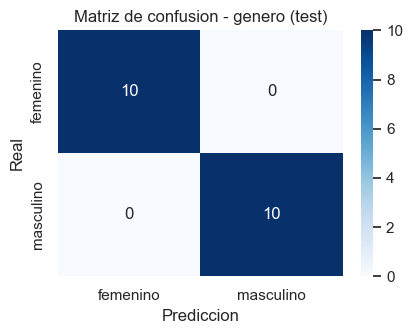

Pares mas confundidos (genero):


'Ninguno (sin errores en test).'

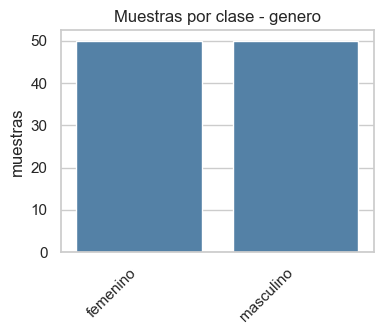


MODELO: NUMEROS
Clases (10): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Muestras por clase: {'0': 50, '1': 50, '2': 50, '3': 50, '4': 50, '5': 50, '6': 50, '7': 50, '8': 50, '9': 50}
Balance min/max: 50 / 50  (ratio 1.00)
Total: 500  ->  train/val/test = 320 / 80 / 100
Entrada del modelo (frames, features): (90, 63)

Accuracy global (test): 0.9400  (94.00%)   |   F1 macro: 0.9394
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       0.67      0.80      0.73        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00        10
           7       1.00      1.00      1.00        10
           8       1.00      1.00      1.00        10
           9       0.75      0.60      0.67        10

    accuracy

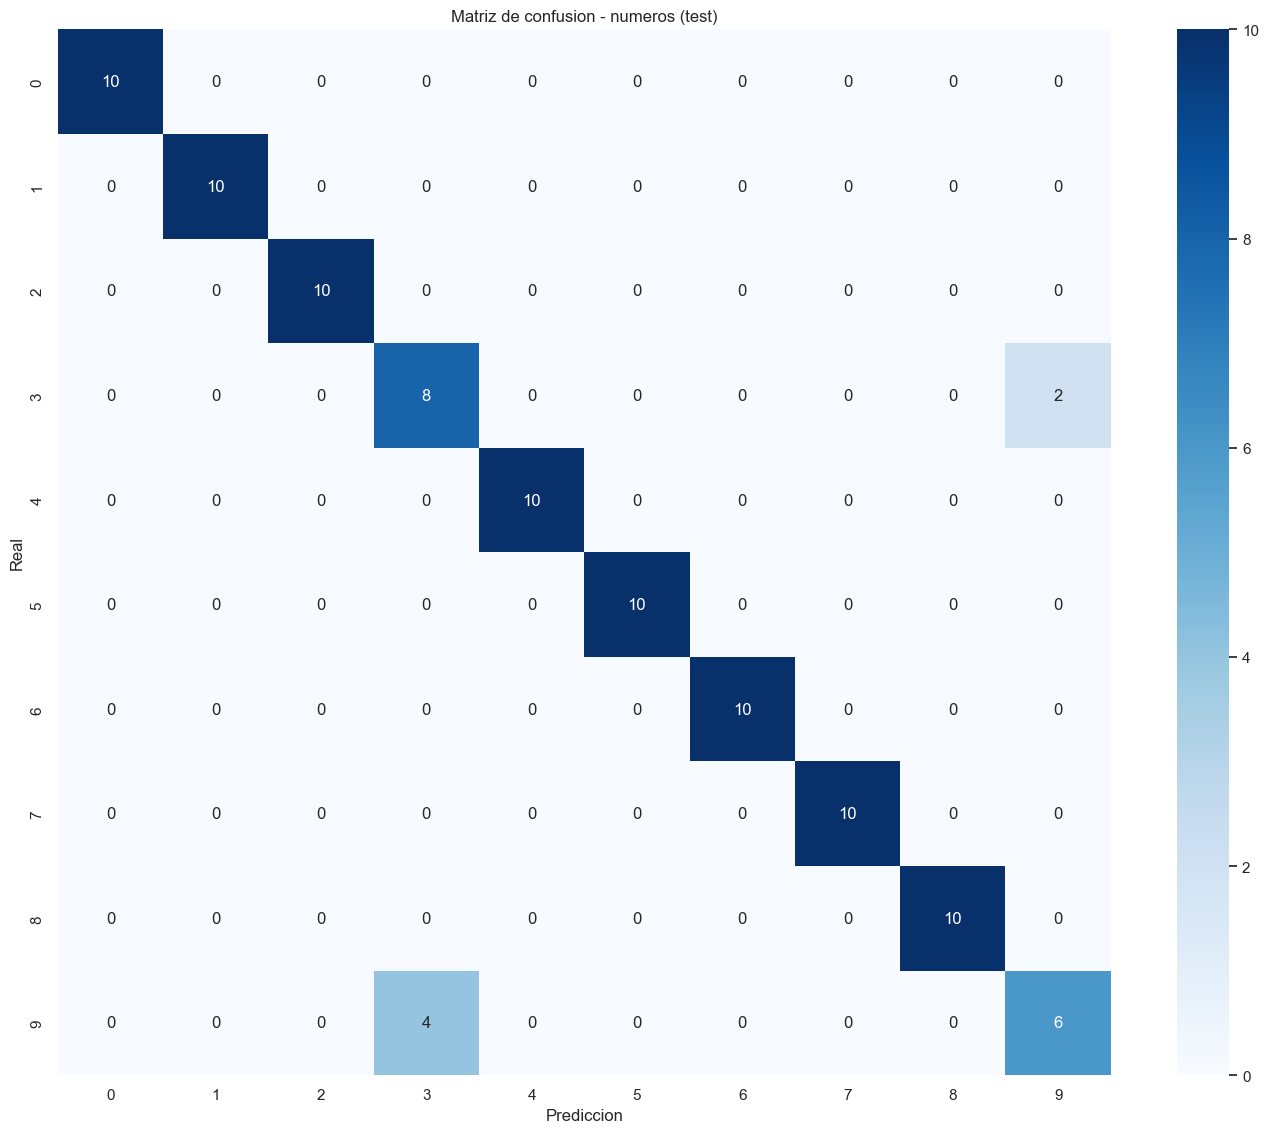

Pares mas confundidos (numeros):


,real,predicha,veces
0,9,3,4
1,3,9,2


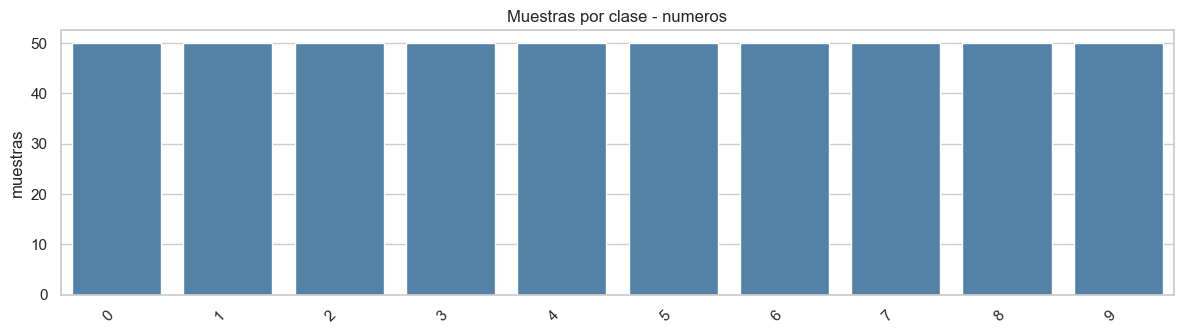


MODELO: DIAS
Clases (7): ['domingo', 'jueves', 'lunes', 'martes', 'miercoles', 'sabado', 'viernes']
Muestras por clase: {'domingo': 50, 'jueves': 50, 'lunes': 50, 'martes': 50, 'miercoles': 50, 'sabado': 50, 'viernes': 50}
Balance min/max: 50 / 50  (ratio 1.00)
Total: 350  ->  train/val/test = 224 / 56 / 70
Entrada del modelo (frames, features): (90, 63)

Accuracy global (test): 1.0000  (100.00%)   |   F1 macro: 1.0000
              precision    recall  f1-score   support

     domingo       1.00      1.00      1.00        10
      jueves       1.00      1.00      1.00        10
       lunes       1.00      1.00      1.00        10
      martes       1.00      1.00      1.00        10
   miercoles       1.00      1.00      1.00        10
      sabado       1.00      1.00      1.00        10
     viernes       1.00      1.00      1.00        10

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00 

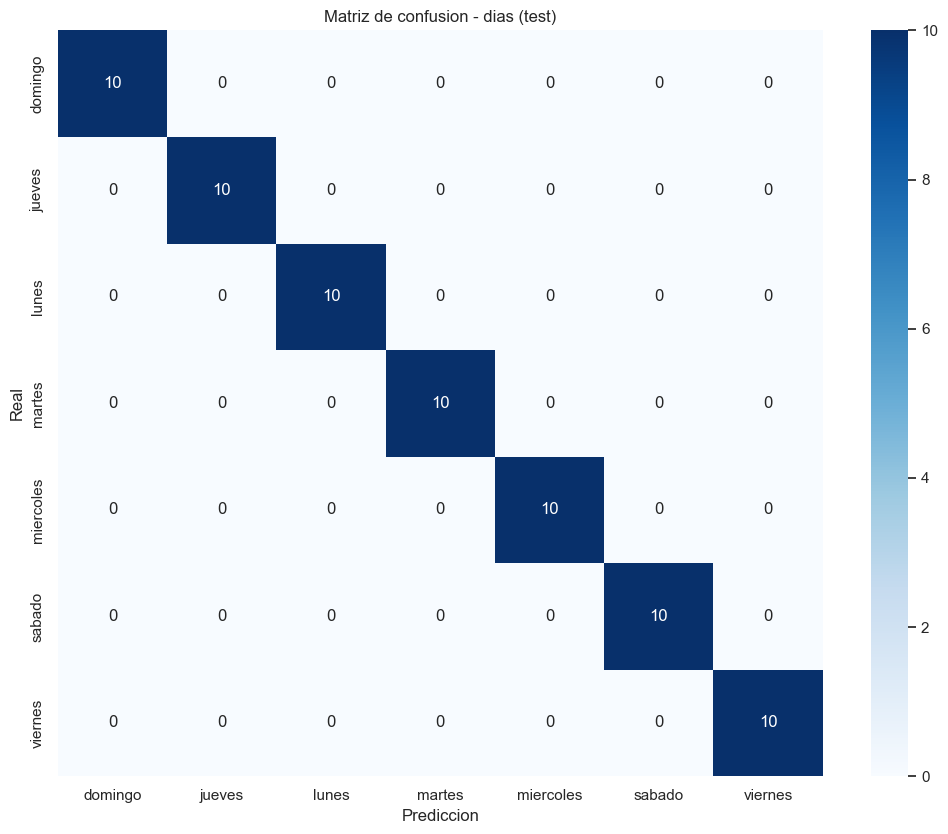

Pares mas confundidos (dias):


'Ninguno (sin errores en test).'

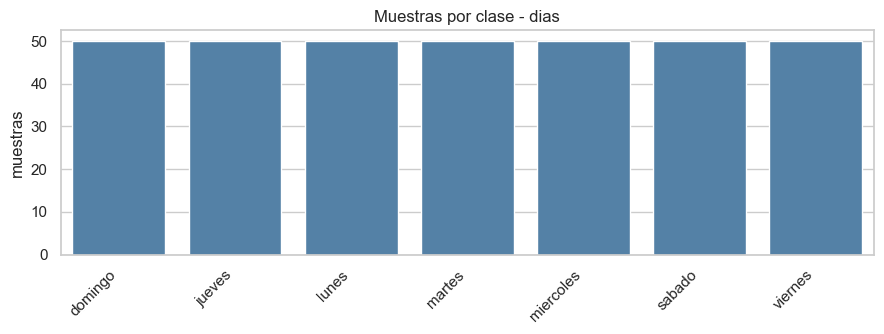


MODELO: MESES
Clases (12): ['abril', 'agosto', 'diciembre', 'enero', 'febrero', 'julio', 'junio', 'marzo', 'mayo', 'noviembre', 'octubre', 'septiembre']
Muestras por clase: {'abril': 50, 'agosto': 50, 'diciembre': 50, 'enero': 50, 'febrero': 50, 'julio': 50, 'junio': 50, 'marzo': 50, 'mayo': 50, 'noviembre': 50, 'octubre': 50, 'septiembre': 50}
Balance min/max: 50 / 50  (ratio 1.00)
Total: 600  ->  train/val/test = 384 / 96 / 120
Entrada del modelo (frames, features): (90, 63)

Accuracy global (test): 1.0000  (100.00%)   |   F1 macro: 1.0000
              precision    recall  f1-score   support

       abril       1.00      1.00      1.00        10
      agosto       1.00      1.00      1.00        10
   diciembre       1.00      1.00      1.00        10
       enero       1.00      1.00      1.00        10
     febrero       1.00      1.00      1.00        10
       julio       1.00      1.00      1.00        10
       junio       1.00      1.00      1.00        10
       marzo      

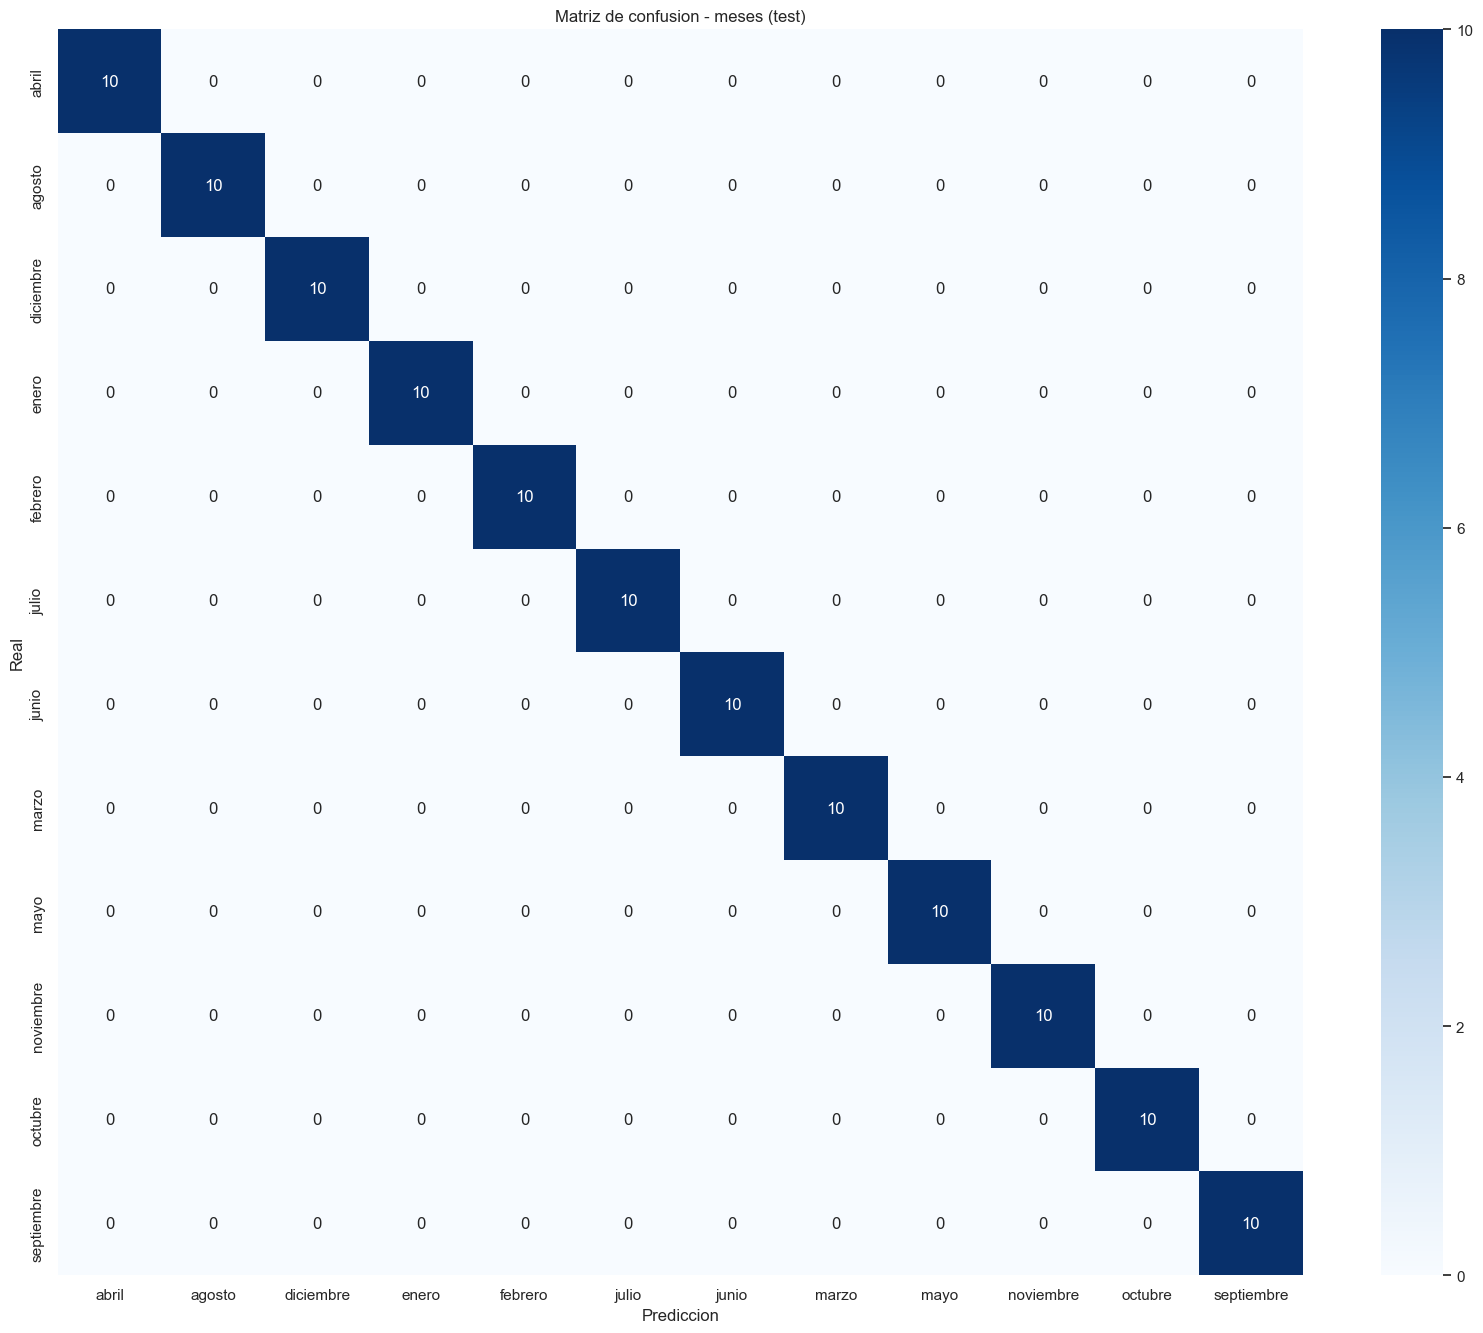

Pares mas confundidos (meses):


'Ninguno (sin errores en test).'

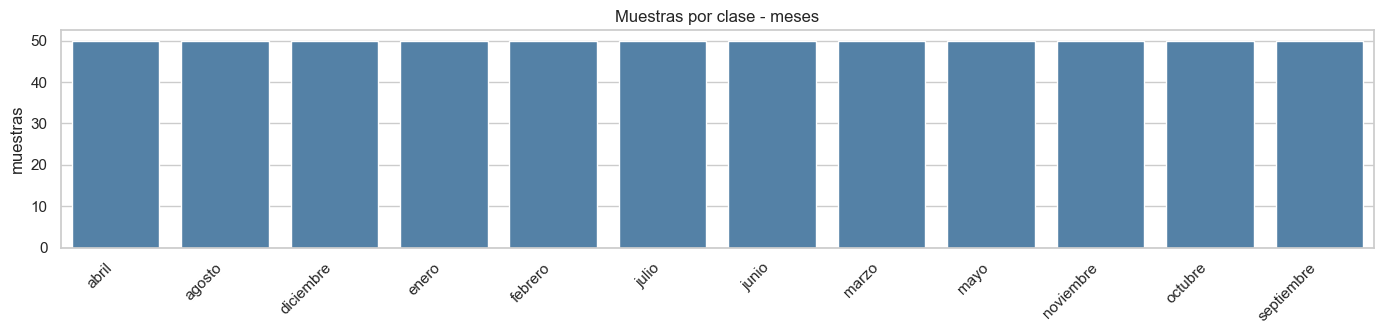


MODELO: HUESPEDES
Clases (5): ['1', '2', '3', 'adulto', 'nino']
Muestras por clase: {'1': 50, '2': 50, '3': 50, 'adulto': 50, 'nino': 50}
Balance min/max: 50 / 50  (ratio 1.00)
Total: 250  ->  train/val/test = 160 / 40 / 50
Entrada del modelo (frames, features): (90, 168)

Accuracy global (test): 1.0000  (100.00%)   |   F1 macro: 1.0000
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
      adulto       1.00      1.00      1.00        10
        nino       1.00      1.00      1.00        10

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



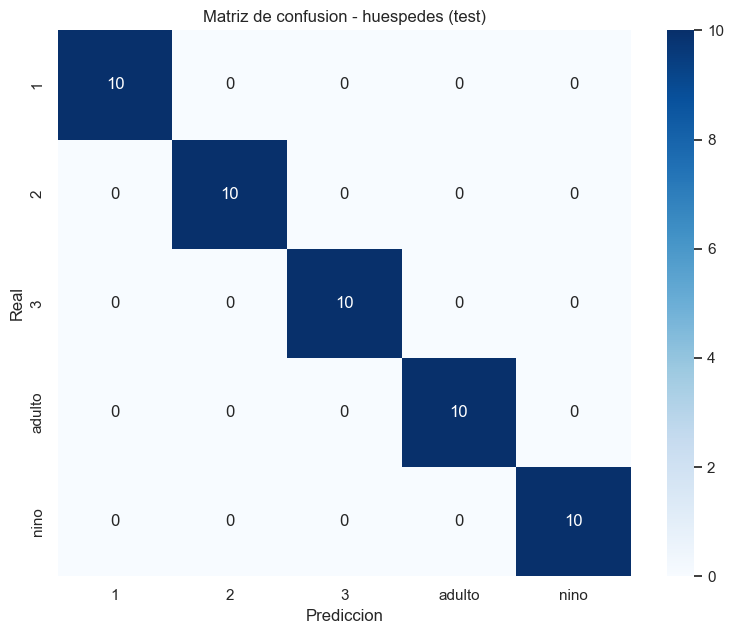

Pares mas confundidos (huespedes):


'Ninguno (sin errores en test).'

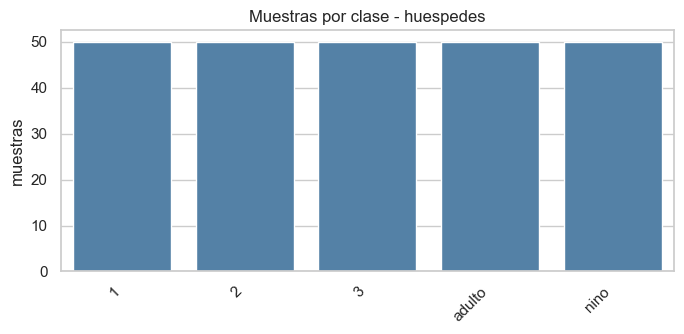

In [6]:
def evaluate_model(cfg):
    print('\n' + '=' * 64)
    print('MODELO:', cfg['name'].upper())
    print('=' * 64)
    class_names = load_label_names(cfg['labels'])
    ddir = data_dir_for(cfg)
    X, y, counts = load_dataset(ddir, class_names)
    n_classes = len(class_names)

    # Balance
    print('Clases (%d):' % n_classes, class_names)
    print('Muestras por clase:', counts)
    cnt = np.bincount(y, minlength=n_classes)
    print('Balance min/max: %d / %d  (ratio %.2f)' % (cnt.min(), cnt.max(), cnt.max() / max(cnt.min(), 1)))

    # Split reproducible (igual que train_model.py)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
    n_total = len(X); n_test = len(X_te)
    n_val = int(round(TEST_SIZE * len(X_tr))); n_train = len(X_tr) - n_val
    print('Total: %d  ->  train/val/test = %d / %d / %d' % (n_total, n_train, n_val, n_test))
    print('Entrada del modelo (frames, features):', X.shape[1:])

    # Inferencia ONNX sobre el test
    proba = onnx_predict(cfg['onnx'], X_te)
    y_pred = proba.argmax(1)
    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average='macro', zero_division=0)
    print('\nAccuracy global (test): %.4f  (%.2f%%)   |   F1 macro: %.4f' % (acc, acc * 100, f1m))
    print(classification_report(y_te, y_pred, labels=list(range(n_classes)),
                                target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_te, y_pred, labels=list(range(n_classes)))
    plot_confusion(cm, class_names, 'Matriz de confusion - %s (test)' % cfg['name'])
    mc = most_confused(cm, class_names)
    print('Pares mas confundidos (%s):' % cfg['name'])
    display(mc if len(mc) else 'Ninguno (sin errores en test).')

    # Balance plot
    plt.figure(figsize=(1.0 * n_classes + 2, 3.5))
    sns.barplot(x=list(class_names), y=list(cnt), color='steelblue')
    plt.title('Muestras por clase - %s' % cfg['name']); plt.ylabel('muestras')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

    return {'name': cfg['name'], 'class_names': class_names, 'X': X, 'y': y,
            'y_test': y_te, 'y_pred': y_pred,
            'n_total': n_total, 'n_train': n_train, 'n_val': n_val, 'n_test': n_test,
            'n_features': int(X.shape[-1]), 'accuracy': acc, 'f1_macro': f1m}


results = {}
for cfg in MODELS:
    try:
        results[cfg['name']] = evaluate_model(cfg)
    except Exception as e:
        print('\n[ERROR evaluando %s]: %s' % (cfg['name'], e))

## 6. Tabla comparativa por modelo (ONNX entregado)

,modelo,clases,features,muestras,train/val/test,accuracy,f1_macro
0,genero,2,63,100,64/16/20,1.00,1.0000
1,numeros,10,63,500,320/80/100,0.94,0.9394
2,dias,7,63,350,224/56/70,1.00,1.0000
3,meses,12,63,600,384/96/120,1.00,1.0000
4,huespedes,5,168,250,160/40/50,1.00,1.0000


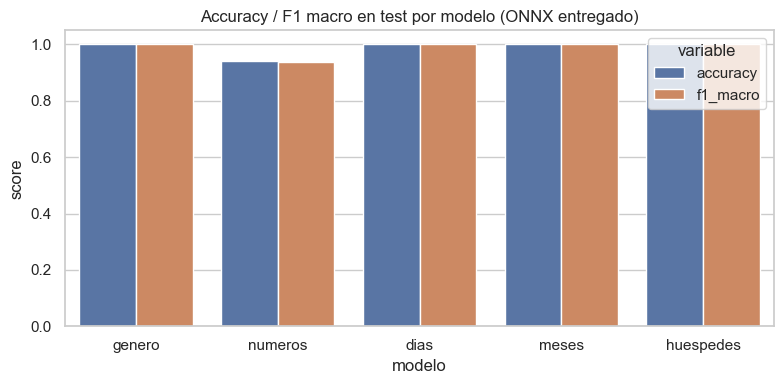

In [7]:
comp = pd.DataFrame([{'modelo': r['name'], 'clases': len(r['class_names']),
                      'features': r['n_features'], 'muestras': r['n_total'],
                      'train/val/test': '%d/%d/%d' % (r['n_train'], r['n_val'], r['n_test']),
                      'accuracy': round(r['accuracy'], 4), 'f1_macro': round(r['f1_macro'], 4)}
                     for r in results.values()])
display(comp)

plt.figure(figsize=(8, 4))
sns.barplot(data=comp.melt(id_vars='modelo', value_vars=['accuracy', 'f1_macro']),
            x='modelo', y='value', hue='variable')
plt.title('Accuracy / F1 macro en test por modelo (ONNX entregado)')
plt.ylim(0, 1.05); plt.ylabel('score'); plt.tight_layout(); plt.show()

## 7. Evaluacion GLOBAL combinada — los 5 modelos como UN solo sistema

Aqui tratamos los 5 modelos como **un unico reconocedor** de todo el vocabulario
(2 + 10 + 7 + 12 + 5 senas). Cada sena se evalua con su modelo especializado y juntamos
**todas** las predicciones en una sola accuracy, un solo `classification_report` y UNA
matriz de confusion.

> Las etiquetas se escriben como `modelo:clase` porque algunas clases se repiten entre
> modelos (p.ej. `1`, `2`, `3` estan en **numeros** y en **huespedes**).
>
> La matriz resulta **block-diagonal**: cada sena se enruta a su modelo y ningun modelo
> puede predecir clases de otro, asi que los errores viven dentro de cada bloque. La
> accuracy global = total de aciertos / total de muestras de test de todos los modelos.

SISTEMA UNIFICADO (todos los modelos como uno solo)
Clases totales   : 36
Muestras de test : 360
ACCURACY GLOBAL  : 0.9833  (98.33%)
F1 macro GLOBAL  : 0.9832

Contribucion por modelo:


,modelo,clases,muestras_test,aciertos,accuracy
0,genero,2,20,20,1.00
1,numeros,10,100,94,0.94
2,dias,7,70,70,1.00
3,meses,12,120,120,1.00
4,huespedes,5,50,50,1.00



Classification report GLOBAL (todas las clases):
                  precision    recall  f1-score   support

 genero:femenino       1.00      1.00      1.00        10
genero:masculino       1.00      1.00      1.00        10
       numeros:0       1.00      1.00      1.00        10
       numeros:1       1.00      1.00      1.00        10
       numeros:2       1.00      1.00      1.00        10
       numeros:3       0.67      0.80      0.73        10
       numeros:4       1.00      1.00      1.00        10
       numeros:5       1.00      1.00      1.00        10
       numeros:6       1.00      1.00      1.00        10
       numeros:7       1.00      1.00      1.00        10
       numeros:8       1.00      1.00      1.00        10
       numeros:9       0.75      0.60      0.67        10
    dias:domingo       1.00      1.00      1.00        10
     dias:jueves       1.00      1.00      1.00        10
      dias:lunes       1.00      1.00      1.00        10
     dias:martes     

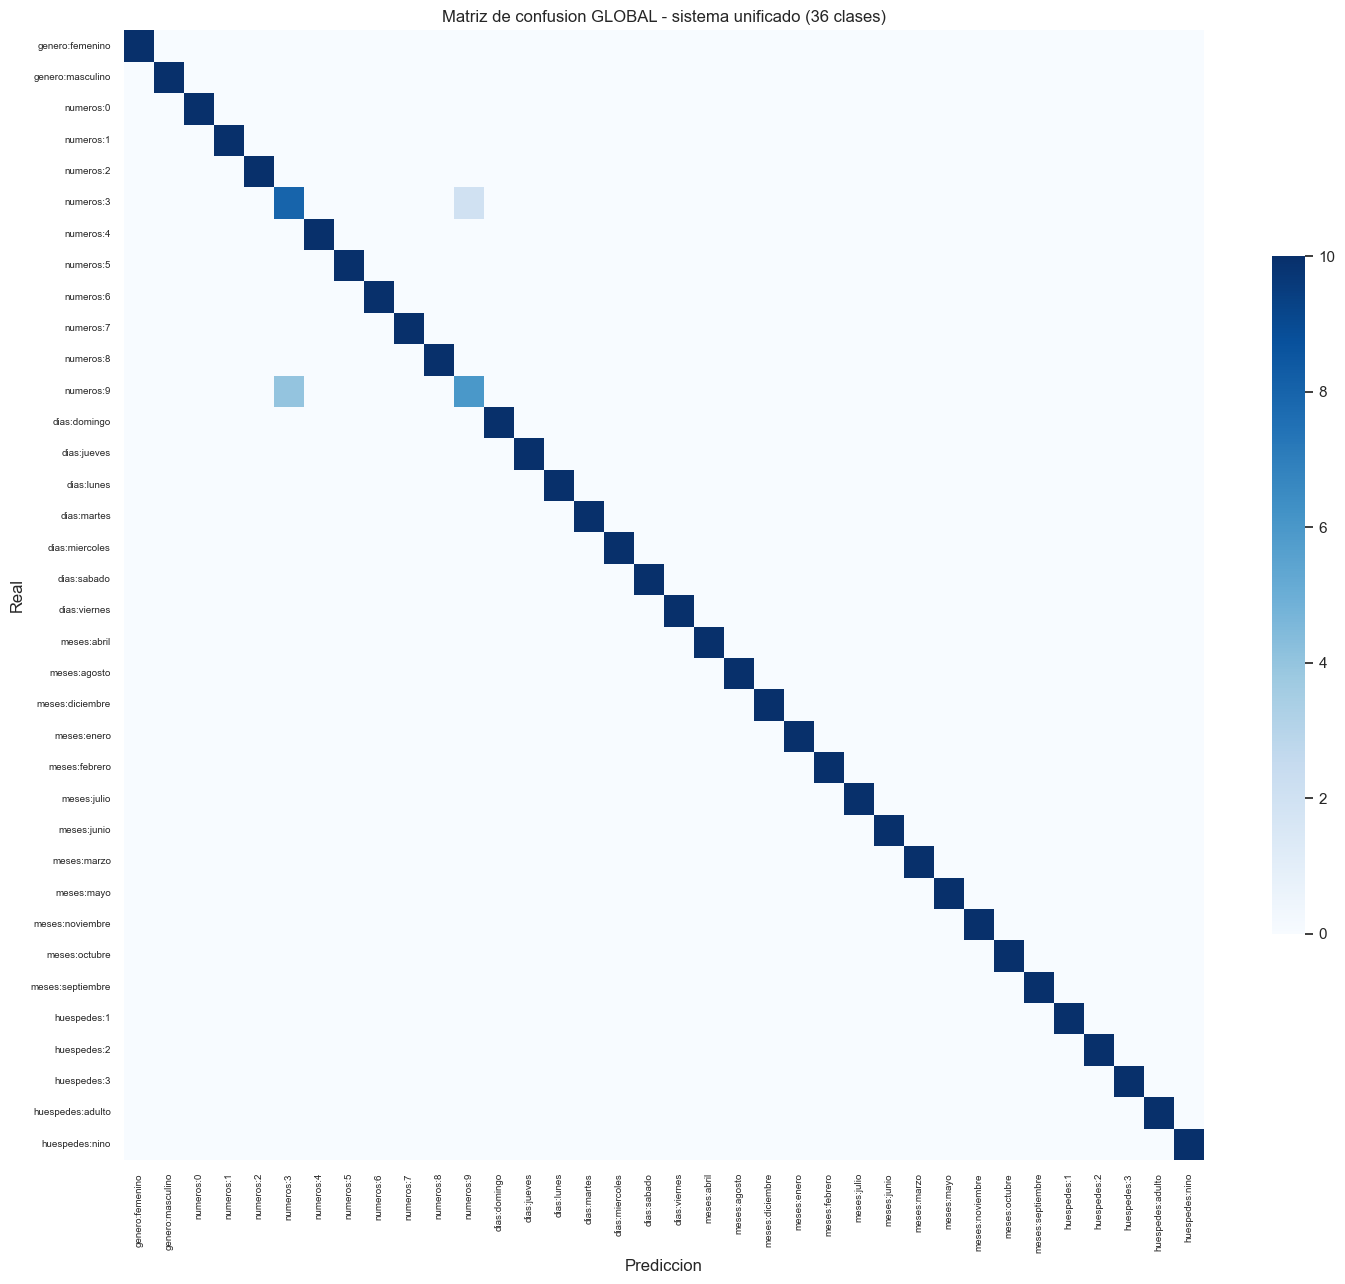

Pares de clases mas confundidos (GLOBAL):


,real,predicha,veces
0,numeros:9,numeros:3,4
1,numeros:3,numeros:9,2


In [8]:
# Juntar las predicciones de todos los modelos con etiquetas "modelo:clase"
global_true, global_pred, contrib = [], [], []
for name, r in results.items():
    cn = r['class_names']; yt = r['y_test']; yp = r['y_pred']
    global_true += ['%s:%s' % (name, cn[i]) for i in yt]
    global_pred += ['%s:%s' % (name, cn[i]) for i in yp]
    correct = int((yt == yp).sum())
    contrib.append({'modelo': name, 'clases': len(cn), 'muestras_test': len(yt),
                    'aciertos': correct, 'accuracy': round(correct / len(yt), 4)})

global_labels = []
for name, r in results.items():
    global_labels += ['%s:%s' % (name, c) for c in r['class_names']]

acc_global = accuracy_score(global_true, global_pred)
f1_global = f1_score(global_true, global_pred, average='macro', zero_division=0)

print('=' * 60)
print('SISTEMA UNIFICADO (todos los modelos como uno solo)')
print('=' * 60)
print('Clases totales   :', len(global_labels))
print('Muestras de test :', len(global_true))
print('ACCURACY GLOBAL  : %.4f  (%.2f%%)' % (acc_global, acc_global * 100))
print('F1 macro GLOBAL  : %.4f' % f1_global)
print('\nContribucion por modelo:')
display(pd.DataFrame(contrib))

print('\nClassification report GLOBAL (todas las clases):')
print(classification_report(global_true, global_pred, labels=global_labels, zero_division=0))

cm_g = confusion_matrix(global_true, global_pred, labels=global_labels)
plt.figure(figsize=(15, 13))
sns.heatmap(cm_g, annot=False, cmap='Blues', xticklabels=global_labels, yticklabels=global_labels,
            cbar_kws={'shrink': 0.6})
plt.title('Matriz de confusion GLOBAL - sistema unificado (%d clases)' % len(global_labels))
plt.xlabel('Prediccion'); plt.ylabel('Real')
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.tight_layout(); plt.show()

print('Pares de clases mas confundidos (GLOBAL):')
mc_g = most_confused(cm_g, global_labels, top=15)
display(mc_g if len(mc_g) else 'Ninguno (sin errores en todo el sistema).')

## 8. Mini-benchmark ADR-09 — RF vs SVM vs XGBoost vs MLP
Clasificadores tabulares sobre las features con *mean-pool* temporal `(muestras, features)`.
Justifica la eleccion del modelo frente a alternativas clasicas.

In [9]:
def tabular_benchmark(X, y):
    Xf = X.mean(axis=1)  # mean-pool temporal -> (muestras, n_features)
    Xtr, Xte, ytr, yte = train_test_split(
        Xf, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
    models = {
        'RandomForest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        'SVM (RBF)':    SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE),
        'MLP':          MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=RANDOM_STATE),
    }
    try:
        from xgboost import XGBClassifier
        models['XGBoost'] = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                          subsample=0.9, eval_metric='mlogloss', random_state=RANDOM_STATE)
    except Exception as e:
        print('  XGBoost no disponible:', e)
    rows = []
    for nm, clf in models.items():
        clf.fit(Xtr, ytr); p = clf.predict(Xte)
        rows.append({'clasificador': nm, 'accuracy': round(accuracy_score(yte, p), 4),
                     'f1_macro': round(f1_score(yte, p, average='macro', zero_division=0), 4)})
    return pd.DataFrame(rows).sort_values('f1_macro', ascending=False).reset_index(drop=True)

adr09 = {}
for name, r in results.items():
    print('\n### ADR-09 -', name, '(features mean-pool =', r['n_features'], ')')
    df = tabular_benchmark(r['X'], r['y'])
    df.insert(0, 'modelo', name)
    adr09[name] = df
    display(df)


### ADR-09 - genero (features mean-pool = 63 )


,modelo,clasificador,accuracy,f1_macro
0,genero,RandomForest,1.0,1.0
1,genero,SVM (RBF),1.0,1.0
2,genero,MLP,1.0,1.0
3,genero,XGBoost,1.0,1.0



### ADR-09 - numeros (features mean-pool = 63 )


,modelo,clasificador,accuracy,f1_macro
0,numeros,RandomForest,1.00,1.00
1,numeros,SVM (RBF),1.00,1.00
2,numeros,MLP,1.00,1.00
3,numeros,XGBoost,0.99,0.99



### ADR-09 - dias (features mean-pool = 63 )


,modelo,clasificador,accuracy,f1_macro
0,dias,RandomForest,1.0000,1.0000
1,dias,SVM (RBF),1.0000,1.0000
2,dias,MLP,1.0000,1.0000
3,dias,XGBoost,0.9714,0.9711



### ADR-09 - meses (features mean-pool = 63 )


,modelo,clasificador,accuracy,f1_macro
0,meses,RandomForest,1.0,1.0
1,meses,SVM (RBF),1.0,1.0
2,meses,MLP,1.0,1.0
3,meses,XGBoost,1.0,1.0



### ADR-09 - huespedes (features mean-pool = 168 )


,modelo,clasificador,accuracy,f1_macro
0,huespedes,RandomForest,1.0,1.0
1,huespedes,SVM (RBF),1.0,1.0
2,huespedes,MLP,1.0,1.0
3,huespedes,XGBoost,1.0,1.0


## 9. Mini-benchmark ADR-08 — LSTM vs GRU vs 1D-CNN
Sobre las **secuencias** `(frames, features)`. El **LSTM entregado** es el ONNX (su accuracy ya
medida arriba); aqui entrenamos un LSTM, un GRU y una 1D-CNN frescos para comparar arquitecturas.

> Celda **lenta**: entrena 3 redes por modelo. Ajusta `EPOCHS_SEQ` o `BENCH_MODELS` si hace falta.

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

EPOCHS_SEQ = 50
BENCH_MODELS = [m['name'] for m in MODELS]   # subconjunto si quieres ir mas rapido

def make_lstm(inp, ncl):
    return keras.Sequential([layers.Input(inp),
        layers.LSTM(64, return_sequences=True), layers.Dropout(0.5),
        layers.LSTM(64), layers.Dropout(0.5),
        layers.Dense(32, activation='relu'), layers.Dropout(0.5),
        layers.Dense(ncl, activation='softmax')])

def make_gru(inp, ncl):
    return keras.Sequential([layers.Input(inp),
        layers.GRU(64, return_sequences=True), layers.Dropout(0.5),
        layers.GRU(64), layers.Dropout(0.5),
        layers.Dense(32, activation='relu'), layers.Dropout(0.5),
        layers.Dense(ncl, activation='softmax')])

def make_cnn(inp, ncl):
    return keras.Sequential([layers.Input(inp),
        layers.Conv1D(64, 3, activation='relu', padding='same'), layers.MaxPooling1D(2),
        layers.Conv1D(128, 3, activation='relu', padding='same'), layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'), layers.Dropout(0.5),
        layers.Dense(ncl, activation='softmax')])

def seq_benchmark(X, y, ncl):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
    inp = X.shape[1:]
    rows = []
    for nm, build in [('LSTM', make_lstm), ('GRU', make_gru), ('1D-CNN', make_cnn)]:
        keras.utils.set_random_seed(RANDOM_STATE)
        net = build(inp, ncl)
        net.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        net.fit(Xtr, ytr, validation_split=0.2, epochs=EPOCHS_SEQ, batch_size=16, verbose=0, callbacks=[es])
        p = net.predict(Xte, verbose=0).argmax(1)
        rows.append({'arquitectura': nm, 'accuracy': round(accuracy_score(yte, p), 4),
                     'f1_macro': round(f1_score(yte, p, average='macro', zero_division=0), 4)})
    return pd.DataFrame(rows).sort_values('f1_macro', ascending=False).reset_index(drop=True)

adr08 = {}
for name in BENCH_MODELS:
    r = results.get(name)
    if r is None:
        continue
    print('\n### ADR-08 -', name)
    df = seq_benchmark(r['X'], r['y'], len(r['class_names']))
    # fila de referencia: el LSTM entregado (ONNX)
    df = pd.concat([df, pd.DataFrame([{'arquitectura': 'LSTM (ONNX entregado)',
                    'accuracy': round(r['accuracy'], 4), 'f1_macro': round(r['f1_macro'], 4)}])],
                   ignore_index=True)
    df.insert(0, 'modelo', name)
    adr08[name] = df
    display(df)


### ADR-08 - genero


,modelo,arquitectura,accuracy,f1_macro
0,genero,LSTM,1.0,1.0
1,genero,GRU,1.0,1.0
2,genero,1D-CNN,1.0,1.0
3,genero,LSTM (ONNX entregado),1.0,1.0



### ADR-08 - numeros


,modelo,arquitectura,accuracy,f1_macro
0,numeros,GRU,1.00,1.0000
1,numeros,1D-CNN,1.00,1.0000
2,numeros,LSTM,0.84,0.8103
3,numeros,LSTM (ONNX entregado),0.94,0.9394



### ADR-08 - dias


,modelo,arquitectura,accuracy,f1_macro
0,dias,LSTM,1.0,1.0
1,dias,GRU,1.0,1.0
2,dias,1D-CNN,1.0,1.0
3,dias,LSTM (ONNX entregado),1.0,1.0



### ADR-08 - meses


,modelo,arquitectura,accuracy,f1_macro
0,meses,GRU,1.0000,1.0000
1,meses,1D-CNN,1.0000,1.0000
2,meses,LSTM,0.9917,0.9916
3,meses,LSTM (ONNX entregado),1.0000,1.0000



### ADR-08 - huespedes


,modelo,arquitectura,accuracy,f1_macro
0,huespedes,LSTM,1.0,1.0
1,huespedes,GRU,1.0,1.0
2,huespedes,1D-CNN,1.0,1.0
3,huespedes,LSTM (ONNX entregado),1.0,1.0


## 10. Curva de aprendizaje
El ONNX no guarda el `history` de entrenamiento, asi que no hay curva loss/accuracy por epoca
del modelo entregado. Como equivalente (ADR), mostramos la `learning_curve` de sklearn sobre un
Random Forest con las features mean-pool: como mejora el desempeno al aumentar las muestras.

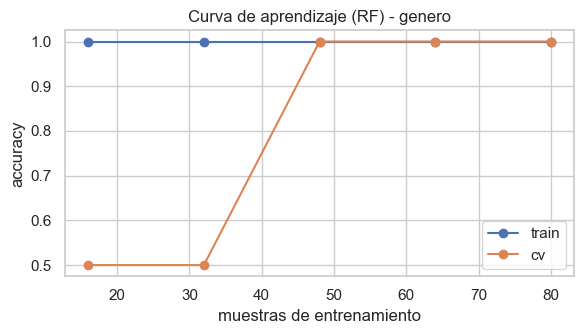

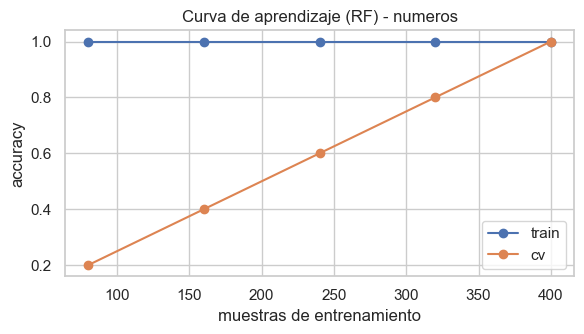

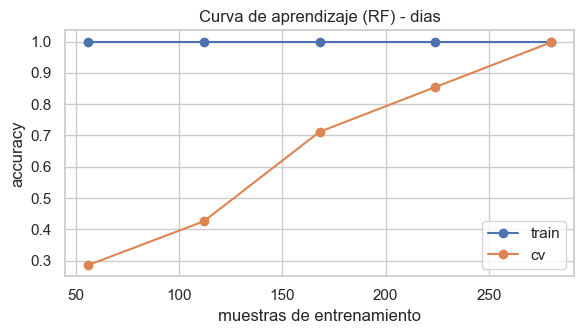

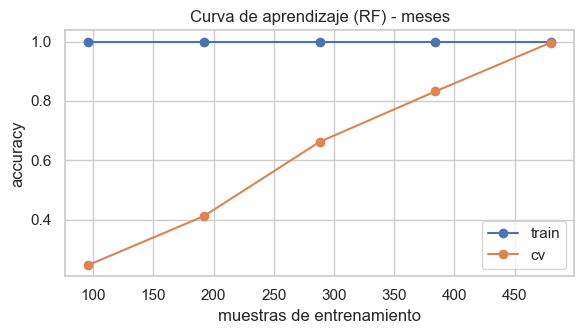

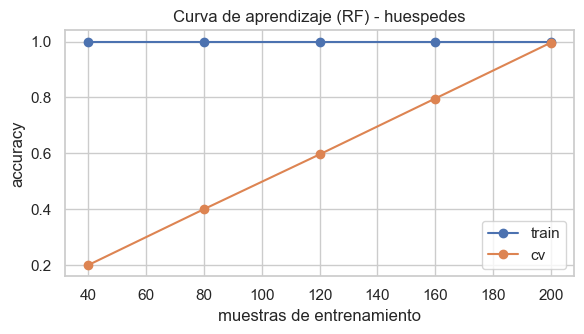

In [11]:
for name, r in results.items():
    Xf = r['X'].mean(axis=1); y = r['y']
    kmin = int(np.bincount(y).min())
    nsplit = max(2, min(5, kmin))
    cv = StratifiedKFold(n_splits=nsplit, shuffle=True, random_state=RANDOM_STATE)
    sizes, tr_sc, va_sc = learning_curve(
        RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        Xf, y, cv=cv, train_sizes=np.linspace(0.2, 1.0, 5), scoring='accuracy', n_jobs=-1)
    plt.figure(figsize=(6, 3.5))
    plt.plot(sizes, tr_sc.mean(1), 'o-', label='train')
    plt.plot(sizes, va_sc.mean(1), 'o-', label='cv')
    plt.title('Curva de aprendizaje (RF) - %s' % name)
    plt.xlabel('muestras de entrenamiento'); plt.ylabel('accuracy')
    plt.legend(); plt.tight_layout(); plt.show()

## 11. Resumen para la defensa

In [12]:
print('=' * 60); print('RESUMEN GLOBAL'); print('=' * 60)
print('\n-- Arquitectura / dimensiones (estatico, del ONNX) --')
display(static_df)
print('\n-- Desempeno en test por modelo (ONNX entregado) --')
display(comp)
print('\n-- SISTEMA UNIFICADO (todos los modelos como uno solo) --')
print('Accuracy global: %.4f  |  F1 macro global: %.4f  |  %d clases, %d muestras de test'
      % (acc_global, f1_global, len(global_labels), len(global_true)))
display(pd.DataFrame(contrib))
print('\n-- ADR-09: clasificadores tabulares (RF/SVM/XGB/MLP) --')
for name, df in adr09.items():
    display(df)
print('\n-- ADR-08: arquitecturas de secuencia (LSTM/GRU/1D-CNN) --')
for name, df in adr08.items():
    display(df)
print('\nListo.')

RESUMEN GLOBAL

-- Arquitectura / dimensiones (estatico, del ONNX) --


,modelo,ventana(frames),features,clases,parametros,tam(KB)
0,genero,90,63,2,68456,271.6
1,numeros,90,63,10,68720,272.6
2,dias,90,63,7,68621,272.2
3,meses,90,63,12,68786,272.9
4,huespedes,90,168,5,95435,377.0



-- Desempeno en test por modelo (ONNX entregado) --


,modelo,clases,features,muestras,train/val/test,accuracy,f1_macro
0,genero,2,63,100,64/16/20,1.00,1.0000
1,numeros,10,63,500,320/80/100,0.94,0.9394
2,dias,7,63,350,224/56/70,1.00,1.0000
3,meses,12,63,600,384/96/120,1.00,1.0000
4,huespedes,5,168,250,160/40/50,1.00,1.0000



-- SISTEMA UNIFICADO (todos los modelos como uno solo) --
Accuracy global: 0.9833  |  F1 macro global: 0.9832  |  36 clases, 360 muestras de test


...

,modelo,arquitectura,accuracy,f1_macro
0,numeros,GRU,1.00,1.0000
1,numeros,1D-CNN,1.00,1.0000
2,numeros,LSTM,0.84,0.8103
3,numeros,LSTM (ONNX entregado),0.94,0.9394


,modelo,arquitectura,accuracy,f1_macro
0,dias,LSTM,1.0,1.0
1,dias,GRU,1.0,1.0
2,dias,1D-CNN,1.0,1.0
3,dias,LSTM (ONNX entregado),1.0,1.0


,modelo,arquitectura,accuracy,f1_macro
0,meses,GRU,1.0000,1.0000
1,meses,1D-CNN,1.0000,1.0000
2,meses,LSTM,0.9917,0.9916
3,meses,LSTM (ONNX entregado),1.0000,1.0000


,modelo,arquitectura,accuracy,f1_macro
0,huespedes,LSTM,1.0,1.0
1,huespedes,GRU,1.0,1.0
2,huespedes,1D-CNN,1.0,1.0
3,huespedes,LSTM (ONNX entregado),1.0,1.0



Listo.
